# Transformer Set Deep SVDD per Emerging Jets

Questo notebook implementa il passo successivo rispetto al Transformer Set Autoencoder.

Nel notebook precedente abbiamo visto:

```text
Transformer reconstruction score AUC ~ 0.80
Transformer latent logistic regression AUC ~ 0.99
Train vs test background AUC ~ 0.50
```

Quindi il Transformer produce un embedding latente molto informativo, ma il reconstruction error non sfrutta tutta questa informazione.

Qui cambiamo anomaly score:

```text
Transformer Encoder sui tracks
-> embedding latente del jet z
-> Deep SVDD loss sul background
-> anomaly score = ||z - c||^2
```

dove `c` è il centro degli embedding background.

Il modello è ancora unsupervised/anomaly detection:

```text
training: solo background-like jets
test: background vs signal displaced
```

Il notebook usa direttamente gli `.npz` già preprocessati, senza rigenerare dataset pesanti.

## 1. Import e GPU

In [1]:
from pathlib import Path
import json
import copy
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split

from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

np.random.seed(42)
torch.manual_seed(42)

print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA version:", torch.version.cuda)
print("GPU count:", torch.cuda.device_count())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Torch: 2.12.0+cu126
CUDA available: True
CUDA version: 12.6
GPU count: 1
GPU: NVIDIA GeForce RTX 4050 Laptop GPU
Using device: cuda


## 2. Caricamento dataset preprocessati

In [2]:
CANDIDATE_DATASETS = [
    {
        "name": "processed_flow",
        "dir": Path("processed_flow"),
        "files": {
            "val": "processed_flow_jet_track_val.npz",
            "test_background": "processed_flow_jet_track_test_background.npz",
            "test_signal": "processed_flow_jet_track_test_signal.npz",
        },
    },
    {
        "name": "processed_clean",
        "dir": Path("processed_clean"),
        "files": {
            "val": "processed_clean_jet_track_val.npz",
            "test_background": "processed_clean_jet_track_test_background.npz",
            "test_signal": "processed_clean_jet_track_test_signal.npz",
        },
    },
    {
        "name": "processed",
        "dir": Path("processed"),
        "files": {
            "val": "processed_jet_track_val.npz",
            "test_background": "processed_jet_track_test_background.npz",
            "test_signal": "processed_jet_track_test_signal.npz",
        },
    },
]

selected = None

for candidate in CANDIDATE_DATASETS:
    base = candidate["dir"]
    files = {k: base / v for k, v in candidate["files"].items()}
    ok = all(path.exists() for path in files.values())

    print(candidate["name"], "available:", ok)
    for k, path in files.items():
        print(" ", k, "->", path, "exists:", path.exists())

    if ok and selected is None:
        selected = (candidate["name"], files)

if selected is None:
    raise FileNotFoundError("Nessun dataset preprocessato trovato.")

DATASET_NAME, processed_files = selected

OUTPUT_DIR = Path("outputs_transformer_svdd")
OUTPUT_DIR.mkdir(exist_ok=True)

print("\nUsing dataset:", DATASET_NAME)
print(processed_files)

processed_flow available: True
  val -> processed_flow\processed_flow_jet_track_val.npz exists: True
  test_background -> processed_flow\processed_flow_jet_track_test_background.npz exists: True
  test_signal -> processed_flow\processed_flow_jet_track_test_signal.npz exists: True
processed_clean available: True
  val -> processed_clean\processed_clean_jet_track_val.npz exists: True
  test_background -> processed_clean\processed_clean_jet_track_test_background.npz exists: True
  test_signal -> processed_clean\processed_clean_jet_track_test_signal.npz exists: True
processed available: True
  val -> processed\processed_jet_track_val.npz exists: True
  test_background -> processed\processed_jet_track_test_background.npz exists: True
  test_signal -> processed\processed_jet_track_test_signal.npz exists: True

Using dataset: processed_flow
{'val': WindowsPath('processed_flow/processed_flow_jet_track_val.npz'), 'test_background': WindowsPath('processed_flow/processed_flow_jet_track_test_backg

## 3. Carica array

In [3]:
data_train = np.load(processed_files["val"], allow_pickle=True)
data_bg = np.load(processed_files["test_background"], allow_pickle=True)
data_sig = np.load(processed_files["test_signal"], allow_pickle=True)

X_jets_train = data_train["X_jets"].astype(np.float32)
X_tracks_train = data_train["X_tracks"].astype(np.float32)
mask_train = data_train["track_mask"].astype(bool)

X_jets_bg = data_bg["X_jets"].astype(np.float32)
X_tracks_bg = data_bg["X_tracks"].astype(np.float32)
mask_bg = data_bg["track_mask"].astype(bool)

X_jets_sig = data_sig["X_jets"].astype(np.float32)
X_tracks_sig = data_sig["X_tracks"].astype(np.float32)
mask_sig = data_sig["track_mask"].astype(bool)

jet_feature_names = list(data_train["jet_feature_names"])
track_feature_names = list(data_train["track_feature_names"])

print("train:", X_jets_train.shape, X_tracks_train.shape, mask_train.shape)
print("background:", X_jets_bg.shape, X_tracks_bg.shape, mask_bg.shape)
print("signal:", X_jets_sig.shape, X_tracks_sig.shape, mask_sig.shape)

print("\nJet features:", jet_feature_names)
print("\nTrack features:", track_feature_names)

if "y" in data_train:
    print("\ntrain y:", np.unique(data_train["y"], return_counts=True))
if "meta_isDisplaced" in data_train:
    print("train meta_isDisplaced:", np.unique(data_train["meta_isDisplaced"], return_counts=True))
if "meta_isDisplaced" in data_sig:
    print("signal meta_isDisplaced:", np.unique(data_sig["meta_isDisplaced"], return_counts=True))

train: (100000, 14) (100000, 200, 12) (100000, 200)
background: (100000, 14) (100000, 200, 12) (100000, 200)
signal: (61966, 14) (61966, 200, 12) (61966, 200)

Jet features: ['pt', 'eta', 'mass', 'energy', 'Qw_clusterSoftDrop', 'C2_clusterSoftDrop', 'D2_clusterSoftDrop', 'Tau1_clusterSoftDrop', 'Tau2_clusterSoftDrop', 'Tau3_clusterSoftDrop', 'Tau21_clusterSoftDrop', 'Tau32_clusterSoftDrop', 'ECF1_clusterSoftDrop', 'ECF2_clusterSoftDrop']

Track features: ['d0', 'z0SinTheta', 'dphi', 'deta', 'pt_log1p', 'radiusOfFirstHit', 'numberOfPixelHits', 'numberOfSCTHits', 'numberOfSCTHoles', 'numberOfInnermostPixelLayerHits', 'numberOfPixelSharedHits', 'numberOfSCTSharedHits']

train y: (array([0]), array([100000]))
train meta_isDisplaced: (array([0], dtype=int32), array([100000]))
signal meta_isDisplaced: (array([0, 1], dtype=int32), array([ 2322, 59644]))


## 4. Filtri

In [4]:
# Training solo background-like.
if "y" in data_train:
    train_filter = data_train["y"] == 0
    print("Using y == 0 for training filter.")
elif "meta_isDisplaced" in data_train:
    train_filter = data_train["meta_isDisplaced"] == 0
    print("Using meta_isDisplaced == 0 for training filter.")
else:
    train_filter = np.ones(X_jets_train.shape[0], dtype=bool)
    print("No train labels found: using all training jets.")

# Signal solo veri displaced, se disponibile.
EVAL_ONLY_TRUE_DISPLACED_SIGNAL = True

if EVAL_ONLY_TRUE_DISPLACED_SIGNAL and "meta_isDisplaced" in data_sig:
    sig_filter = data_sig["meta_isDisplaced"] == 1
    print("Using only true displaced signal jets.")
else:
    sig_filter = np.ones(X_jets_sig.shape[0], dtype=bool)
    print("Using all signal jets.")

# Rimuovi jet senza tracce valide.
train_nonempty = mask_train.sum(axis=1) > 0
bg_nonempty = mask_bg.sum(axis=1) > 0
sig_nonempty = mask_sig.sum(axis=1) > 0

print("\nZero-track jets:")
print("train:", np.sum(~train_nonempty), "/", len(train_nonempty))
print("background:", np.sum(~bg_nonempty), "/", len(bg_nonempty))
print("signal:", np.sum(~sig_nonempty), "/", len(sig_nonempty))

train_filter = train_filter & train_nonempty
bg_filter = bg_nonempty
sig_filter = sig_filter & sig_nonempty

X_jets_train = X_jets_train[train_filter]
X_tracks_train = X_tracks_train[train_filter]
mask_train = mask_train[train_filter]

X_jets_bg = X_jets_bg[bg_filter]
X_tracks_bg = X_tracks_bg[bg_filter]
mask_bg = mask_bg[bg_filter]

X_jets_sig = X_jets_sig[sig_filter]
X_tracks_sig = X_tracks_sig[sig_filter]
mask_sig = mask_sig[sig_filter]

print("\nAfter filters:")
print("train:", X_jets_train.shape, X_tracks_train.shape)
print("background:", X_jets_bg.shape, X_tracks_bg.shape)
print("signal:", X_jets_sig.shape, X_tracks_sig.shape)

Using y == 0 for training filter.
Using only true displaced signal jets.

Zero-track jets:
train: 0 / 100000
background: 0 / 100000
signal: 1 / 61966

After filters:
train: (100000, 14) (100000, 200, 12)
background: (100000, 14) (100000, 200, 12)
signal: (59643, 14) (59643, 200, 12)


## 5. Sanity plot

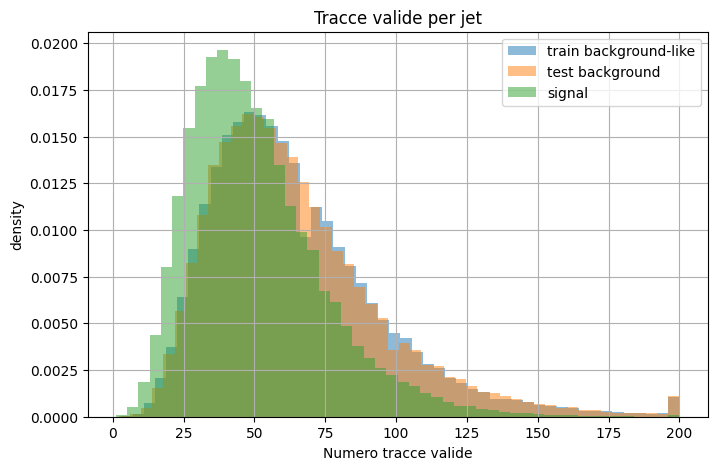

In [5]:
plt.figure(figsize=(8, 5))
plt.hist(mask_train.sum(axis=1), bins=50, density=True, alpha=0.5, label="train background-like")
plt.hist(mask_bg.sum(axis=1), bins=50, density=True, alpha=0.5, label="test background")
plt.hist(mask_sig.sum(axis=1), bins=50, density=True, alpha=0.5, label="signal")
plt.xlabel("Numero tracce valide")
plt.ylabel("density")
plt.title("Tracce valide per jet")
plt.legend()
plt.grid(True)
plt.show()

## 6. Dataset PyTorch

In [6]:
class JetTrackSetDataset(Dataset):
    def __init__(self, X_jets, X_tracks, mask):
        self.X_jets = torch.from_numpy(X_jets).float()
        self.X_tracks = torch.from_numpy(X_tracks).float()
        self.mask = torch.from_numpy(mask).bool()

    def __len__(self):
        return self.X_jets.shape[0]

    def __getitem__(self, idx):
        return self.X_jets[idx], self.X_tracks[idx], self.mask[idx]


full_dataset = JetTrackSetDataset(X_jets_train, X_tracks_train, mask_train)

n_total = len(full_dataset)
n_train = int(0.8 * n_total)
n_val = n_total - n_train

train_dataset, val_dataset = random_split(
    full_dataset,
    [n_train, n_val],
    generator=torch.Generator().manual_seed(42),
)

batch_size = 512

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

center_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Batch size:", batch_size)

Train: 80000
Validation: 20000
Batch size: 512


## 7. Transformer Set Encoder

In [7]:
class TransformerSetEncoder(nn.Module):
    def __init__(
        self,
        n_track_features,
        n_jet_features,
        d_model=96,
        n_heads=4,
        n_layers=3,
        dim_feedforward=256,
        latent_dim=64,
        dropout=0.05,
    ):
        super().__init__()

        self.n_track_features = n_track_features
        self.n_jet_features = n_jet_features
        self.d_model = d_model
        self.latent_dim = latent_dim

        self.track_embed = nn.Sequential(
            nn.Linear(n_track_features, d_model),
            nn.LayerNorm(d_model),
            nn.SiLU(),
            nn.Linear(d_model, d_model),
            nn.LayerNorm(d_model),
            nn.SiLU(),
        )

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
            norm_first=True,
        )

        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=n_layers,
        )

        pooled_dim = 2 * d_model

        self.jet_encoder = nn.Sequential(
            nn.Linear(pooled_dim + n_jet_features, 256),
            nn.LayerNorm(256),
            nn.SiLU(),
            nn.Dropout(dropout),
            nn.Linear(256, latent_dim),
        )

    def masked_pool(self, h, mask):
        mask_f = mask.unsqueeze(-1).float()

        denom = mask_f.sum(dim=1).clamp(min=1.0)
        mean_pool = (h * mask_f).sum(dim=1) / denom

        h_for_max = h.masked_fill(~mask.unsqueeze(-1), -1e9)
        max_pool = h_for_max.max(dim=1).values
        max_pool = torch.where(torch.isfinite(max_pool), max_pool, torch.zeros_like(max_pool))

        return torch.cat([mean_pool, max_pool], dim=1)

    def forward(self, x_jets, x_tracks, mask):
        padding_mask = ~mask

        h = self.track_embed(x_tracks)
        h = h * mask.unsqueeze(-1)

        # Nessun positional encoding: set-like transformer.
        h = self.transformer(h, src_key_padding_mask=padding_mask)
        h = h * mask.unsqueeze(-1)

        pooled = self.masked_pool(h, mask)
        global_input = torch.cat([pooled, x_jets], dim=1)

        z = self.jet_encoder(global_input)

        return z

## 8. Crea encoder

In [8]:
n_track_features = X_tracks_train.shape[-1]
n_jet_features = X_jets_train.shape[-1]

d_model = 96
n_heads = 4
n_layers = 3
dim_feedforward = 256
latent_dim = 64
dropout = 0.05

model = TransformerSetEncoder(
    n_track_features=n_track_features,
    n_jet_features=n_jet_features,
    d_model=d_model,
    n_heads=n_heads,
    n_layers=n_layers,
    dim_feedforward=dim_feedforward,
    latent_dim=latent_dim,
    dropout=dropout,
).to(device)

learning_rate = 1e-4

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=learning_rate,
    weight_decay=1e-5,
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=5,
)

print(model)
print("n_track_features:", n_track_features)
print("n_jet_features:", n_jet_features)
print("latent_dim:", latent_dim)
print("learning_rate:", learning_rate)

C:\Users\andre\AppData\Local\Temp\ipykernel_13096\1289079077.py:39: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(


TransformerSetEncoder(
  (track_embed): Sequential(
    (0): Linear(in_features=12, out_features=96, bias=True)
    (1): LayerNorm((96,), eps=1e-05, elementwise_affine=True, bias=True)
    (2): SiLU()
    (3): Linear(in_features=96, out_features=96, bias=True)
    (4): LayerNorm((96,), eps=1e-05, elementwise_affine=True, bias=True)
    (5): SiLU()
  )
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-2): 3 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=96, out_features=96, bias=True)
        )
        (linear1): Linear(in_features=96, out_features=256, bias=True)
        (dropout): Dropout(p=0.05, inplace=False)
        (linear2): Linear(in_features=256, out_features=96, bias=True)
        (norm1): LayerNorm((96,), eps=1e-05, elementwise_affine=True, bias=True)
        (norm2): LayerNorm((96,), eps=1e-05, elementwise_affine=True, bias=True)
        (dropout1): Dropout(p=0.05, in

## 9. Inizializza centro SVDD

In [9]:
@torch.no_grad()
def compute_center(model, loader, eps=1e-6):
    model.eval()

    zs = []

    for x_jets, x_tracks, mask in loader:
        x_jets = x_jets.to(device, non_blocking=True)
        x_tracks = x_tracks.to(device, non_blocking=True)
        mask = mask.to(device, non_blocking=True)

        z = model(x_jets, x_tracks, mask)
        zs.append(z.cpu())

    z_all = torch.cat(zs, dim=0)
    c = z_all.mean(dim=0)

    # Evita coordinate esattamente zero, come spesso consigliato in Deep SVDD.
    c[(torch.abs(c) < eps) & (c < 0)] = -eps
    c[(torch.abs(c) < eps) & (c >= 0)] = eps

    return c.to(device)


center = compute_center(model, center_loader)

print("center shape:", center.shape)
print("center mean/std:", center.mean().item(), center.std().item())
print("center min/max:", center.min().item(), center.max().item())

center shape: torch.Size([64])
center mean/std: 0.02753055840730667 0.39101284742355347
center min/max: -0.8100051879882812 1.131248950958252


## 10. Loss Deep SVDD

In [10]:
def svdd_loss(z, center):
    dist2 = torch.sum((z - center.unsqueeze(0)) ** 2, dim=1)
    return dist2.mean(), dist2


def evaluate_svdd(model, loader, center):
    model.eval()

    total_loss = 0.0
    total_items = 0

    with torch.no_grad():
        for x_jets, x_tracks, mask in loader:
            x_jets = x_jets.to(device, non_blocking=True)
            x_tracks = x_tracks.to(device, non_blocking=True)
            mask = mask.to(device, non_blocking=True)

            z = model(x_jets, x_tracks, mask)
            loss, _ = svdd_loss(z, center)

            bs = x_jets.shape[0]
            total_loss += loss.item() * bs
            total_items += bs

    return total_loss / total_items

## 11. Training Deep SVDD

In [11]:
n_epochs = 80
early_stopping_patience = 12

train_losses = []
val_losses = []
lr_history = []

best_val_loss = np.inf
best_epoch = -1
best_state_dict = None
epochs_without_improvement = 0

for epoch in range(n_epochs):
    model.train()

    total_loss = 0.0
    total_items = 0

    for x_jets, x_tracks, mask in train_loader:
        x_jets = x_jets.to(device, non_blocking=True)
        x_tracks = x_tracks.to(device, non_blocking=True)
        mask = mask.to(device, non_blocking=True)

        optimizer.zero_grad()

        z = model(x_jets, x_tracks, mask)
        loss, _ = svdd_loss(z, center)

        if not torch.isfinite(loss):
            raise RuntimeError("Loss non finita.")

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()

        bs = x_jets.shape[0]
        total_loss += loss.item() * bs
        total_items += bs

    train_loss = total_loss / total_items
    val_loss = evaluate_svdd(model, val_loader, center)

    scheduler.step(val_loss)
    current_lr = optimizer.param_groups[0]["lr"]

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    lr_history.append(current_lr)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_epoch = epoch + 1
        best_state_dict = copy.deepcopy(model.state_dict())
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    print(
        f"Epoch {epoch+1:03d}/{n_epochs} | "
        f"train SVDD={train_loss:.6f} | "
        f"val SVDD={val_loss:.6f} | "
        f"best={best_val_loss:.6f} @ {best_epoch} | "
        f"lr={current_lr:.2e}"
    )

    if epochs_without_improvement >= early_stopping_patience:
        print("Early stopping.")
        break

if best_state_dict is not None:
    model.load_state_dict(best_state_dict)
    print(f"Loaded best model from epoch {best_epoch} with val loss={best_val_loss:.6f}")

Epoch 001/80 | train SVDD=0.243826 | val SVDD=0.018581 | best=0.018581 @ 1 | lr=1.00e-04
Epoch 002/80 | train SVDD=0.075101 | val SVDD=0.008971 | best=0.008971 @ 2 | lr=1.00e-04
Epoch 003/80 | train SVDD=0.048389 | val SVDD=0.006680 | best=0.006680 @ 3 | lr=1.00e-04
Epoch 004/80 | train SVDD=0.033970 | val SVDD=0.005359 | best=0.005359 @ 4 | lr=1.00e-04
Epoch 005/80 | train SVDD=0.025241 | val SVDD=0.004233 | best=0.004233 @ 5 | lr=1.00e-04
Epoch 006/80 | train SVDD=0.019904 | val SVDD=0.003720 | best=0.003720 @ 6 | lr=1.00e-04
Epoch 007/80 | train SVDD=0.016136 | val SVDD=0.002940 | best=0.002940 @ 7 | lr=1.00e-04
Epoch 008/80 | train SVDD=0.013383 | val SVDD=0.001572 | best=0.001572 @ 8 | lr=1.00e-04
Epoch 009/80 | train SVDD=0.011553 | val SVDD=0.001566 | best=0.001566 @ 9 | lr=1.00e-04
Epoch 010/80 | train SVDD=0.010120 | val SVDD=0.001869 | best=0.001566 @ 9 | lr=1.00e-04
Epoch 011/80 | train SVDD=0.008893 | val SVDD=0.001924 | best=0.001566 @ 9 | lr=1.00e-04
Epoch 012/80 | train 

## 12. Plot training

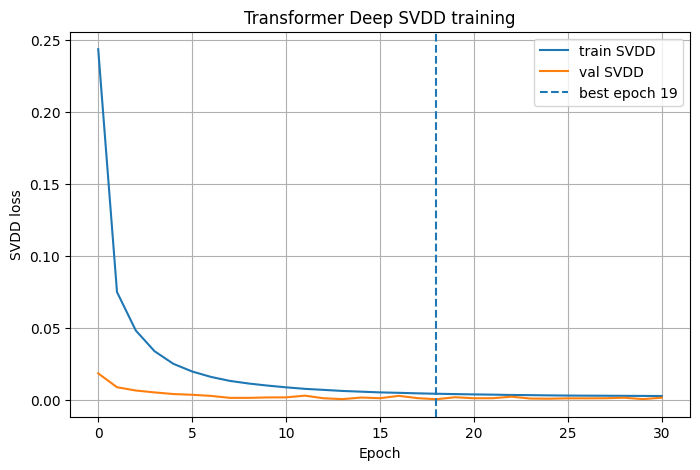

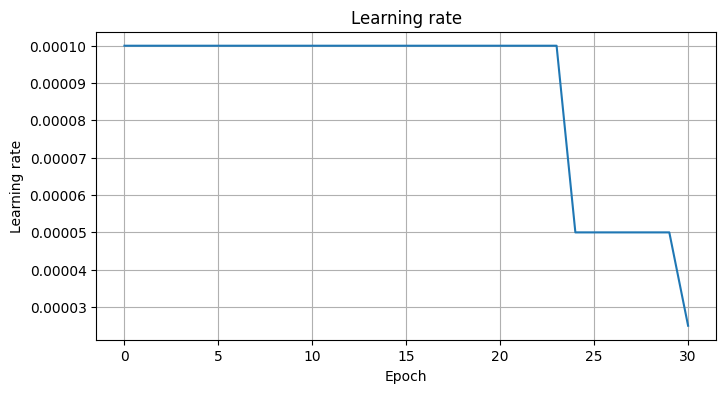

In [12]:
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="train SVDD")
plt.plot(val_losses, label="val SVDD")
plt.axvline(best_epoch - 1, linestyle="--", label=f"best epoch {best_epoch}")
plt.xlabel("Epoch")
plt.ylabel("SVDD loss")
plt.title("Transformer Deep SVDD training")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(lr_history)
plt.xlabel("Epoch")
plt.ylabel("Learning rate")
plt.title("Learning rate")
plt.grid(True)
plt.show()

## 13. Score SVDD

In [13]:
class JetTrackEvalDataset(Dataset):
    def __init__(self, X_jets, X_tracks, mask):
        self.X_jets = torch.from_numpy(X_jets).float()
        self.X_tracks = torch.from_numpy(X_tracks).float()
        self.mask = torch.from_numpy(mask).bool()

    def __len__(self):
        return self.X_jets.shape[0]

    def __getitem__(self, idx):
        return self.X_jets[idx], self.X_tracks[idx], self.mask[idx]


@torch.no_grad()
def compute_svdd_scores(model, X_jets, X_tracks, mask, center, batch_size=1024):
    dataset = JetTrackEvalDataset(X_jets, X_tracks, mask)
    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0,
        pin_memory=torch.cuda.is_available(),
    )

    model.eval()

    scores = []
    embeddings = []

    for x_jets, x_tracks, mask_batch in loader:
        x_jets = x_jets.to(device, non_blocking=True)
        x_tracks = x_tracks.to(device, non_blocking=True)
        mask_batch = mask_batch.to(device, non_blocking=True)

        z = model(x_jets, x_tracks, mask_batch)
        dist2 = torch.sum((z - center.unsqueeze(0)) ** 2, dim=1)

        scores.append(dist2.cpu().numpy())
        embeddings.append(z.cpu().numpy())

    return np.concatenate(scores), np.concatenate(embeddings, axis=0)


scores_train, Z_train = compute_svdd_scores(model, X_jets_train, X_tracks_train, mask_train, center)
scores_bg, Z_bg = compute_svdd_scores(model, X_jets_bg, X_tracks_bg, mask_bg, center)
scores_sig, Z_sig = compute_svdd_scores(model, X_jets_sig, X_tracks_sig, mask_sig, center)

def print_score_summary(name, scores):
    print("\n", name)
    print("mean:", scores.mean())
    print("std:", scores.std())
    print("median:", np.median(scores))
    print("quantiles:", np.percentile(scores, [0, 1, 5, 25, 50, 75, 95, 99, 99.9, 100]))

print_score_summary("train SVDD score", scores_train)
print_score_summary("background SVDD score", scores_bg)
print_score_summary("signal SVDD score", scores_sig)

print("Z_train:", Z_train.shape)
print("Z_bg:", Z_bg.shape)
print("Z_sig:", Z_sig.shape)


 train SVDD score
mean: 0.00063143874
std: 0.00017359904
median: 0.00060780486
quantiles: [0.00018467 0.00033291 0.00039717 0.00051141 0.0006078  0.00072419
 0.00093821 0.00115962 0.00157139 0.00331047]

 background SVDD score
mean: 0.0006316708
std: 0.00017508317
median: 0.0006079909
quantiles: [0.00017782 0.0003315  0.0003967  0.0005113  0.00060799 0.00072363
 0.00094296 0.00116479 0.00156323 0.00519467]

 signal SVDD score
mean: 0.0010514016
std: 0.0003711469
median: 0.0009856011
quantiles: [0.00030234 0.00050052 0.00061287 0.00080861 0.0009856  0.00121118
 0.00170266 0.0023024  0.00357231 0.00806094]
Z_train: (100000, 64)
Z_bg: (100000, 64)
Z_sig: (59643, 64)


## 14. ROC/AUC

Transformer Deep SVDD score         AUC=0.8899 AUC_inv=0.1101 best=0.8899


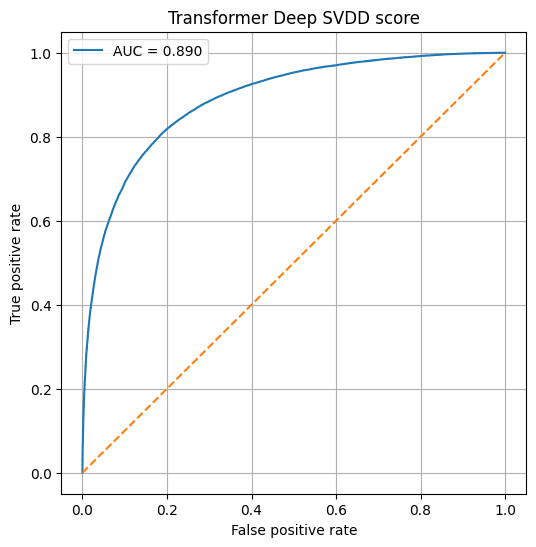

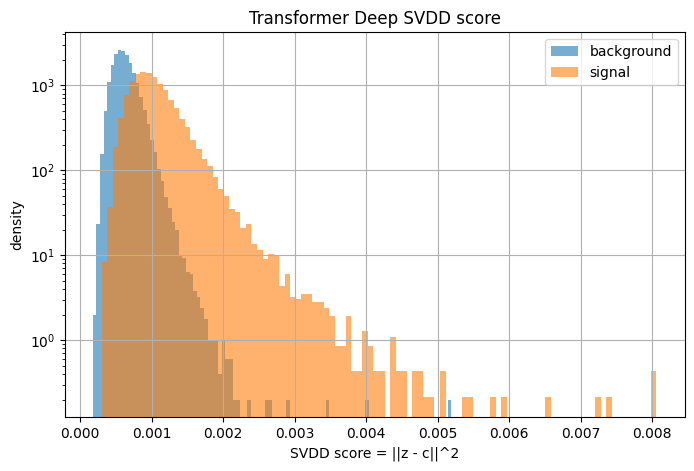

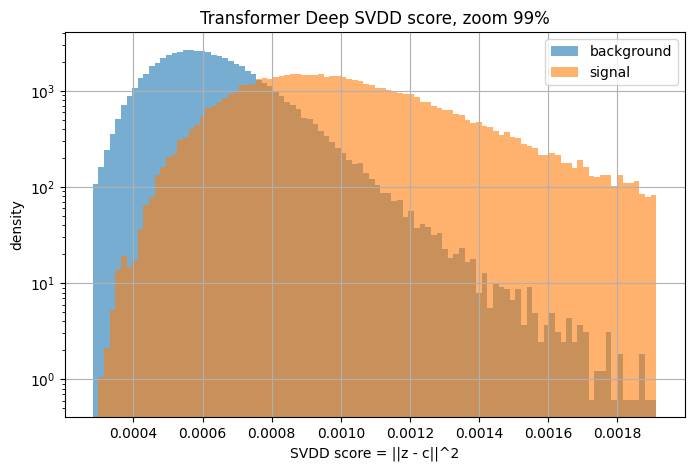

In [14]:
def evaluate_binary_scores(bg_scores, sig_scores, title, make_plot=True):
    y_true = np.concatenate([
        np.zeros_like(bg_scores),
        np.ones_like(sig_scores),
    ])

    y_score = np.concatenate([
        bg_scores,
        sig_scores,
    ])

    auc = roc_auc_score(y_true, y_score)
    auc_inv = roc_auc_score(y_true, -y_score)
    best_auc = max(auc, auc_inv)

    print(f"{title:35s} AUC={auc:.4f} AUC_inv={auc_inv:.4f} best={best_auc:.4f}")

    if make_plot:
        if auc_inv > auc:
            plot_score = -y_score
            label = f"AUC inverted = {auc_inv:.3f}"
        else:
            plot_score = y_score
            label = f"AUC = {auc:.3f}"

        fpr, tpr, _ = roc_curve(y_true, plot_score)

        plt.figure(figsize=(6, 6))
        plt.plot(fpr, tpr, label=label)
        plt.plot([0, 1], [0, 1], linestyle="--")
        plt.xlabel("False positive rate")
        plt.ylabel("True positive rate")
        plt.title(title)
        plt.legend()
        plt.grid(True)
        plt.show()

    return auc, auc_inv, best_auc


def plot_score_distribution(bg_scores, sig_scores, title, zoom_percentile=None):
    plt.figure(figsize=(8, 5))

    if zoom_percentile is not None:
        all_scores = np.concatenate([bg_scores, sig_scores])
        lo = np.percentile(all_scores, 0.1)
        hi = np.percentile(all_scores, zoom_percentile)
        plot_range = (lo, hi)
    else:
        plot_range = None

    plt.hist(bg_scores, bins=100, range=plot_range, density=True, alpha=0.6, label="background")
    plt.hist(sig_scores, bins=100, range=plot_range, density=True, alpha=0.6, label="signal")
    plt.yscale("log")
    plt.xlabel("SVDD score = ||z - c||^2")
    plt.ylabel("density")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()


auc_svdd, auc_svdd_inv, best_auc_svdd = evaluate_binary_scores(
    scores_bg,
    scores_sig,
    "Transformer Deep SVDD score",
    make_plot=True,
)

plot_score_distribution(scores_bg, scores_sig, "Transformer Deep SVDD score")
plot_score_distribution(scores_bg, scores_sig, "Transformer Deep SVDD score, zoom 99%", zoom_percentile=99)

## 15. Train vs test background

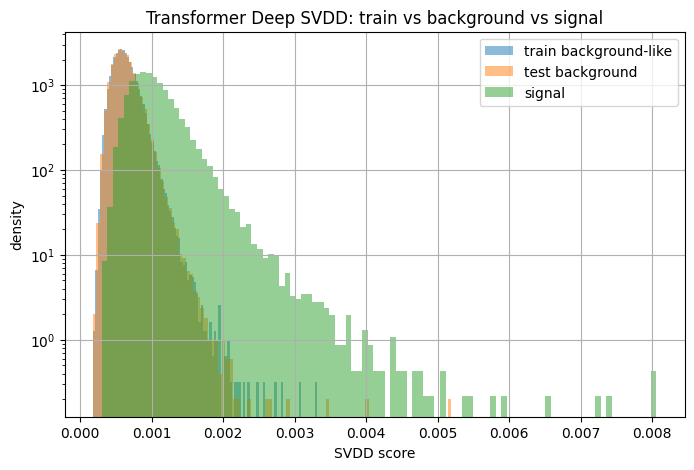

Train vs test background AUC: 0.49994528605
Train vs test background AUC inverted: 0.50005471395
Best train-vs-test-background AUC: 0.50005471395


In [15]:
def compare_train_bg_sig(train_scores, bg_scores, sig_scores, title):
    plt.figure(figsize=(8, 5))
    plt.hist(train_scores, bins=100, density=True, alpha=0.5, label="train background-like")
    plt.hist(bg_scores, bins=100, density=True, alpha=0.5, label="test background")
    plt.hist(sig_scores, bins=100, density=True, alpha=0.5, label="signal")
    plt.yscale("log")
    plt.xlabel("SVDD score")
    plt.ylabel("density")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

    y = np.concatenate([
        np.zeros_like(train_scores),
        np.ones_like(bg_scores),
    ])

    s = np.concatenate([
        train_scores,
        bg_scores,
    ])

    auc_tb = roc_auc_score(y, s)
    auc_tb_inv = roc_auc_score(y, -s)
    best_auc_tb = max(auc_tb, auc_tb_inv)

    print("Train vs test background AUC:", auc_tb)
    print("Train vs test background AUC inverted:", auc_tb_inv)
    print("Best train-vs-test-background AUC:", best_auc_tb)

    return auc_tb, auc_tb_inv, best_auc_tb


auc_train_bg, auc_train_bg_inv, best_auc_train_bg = compare_train_bg_sig(
    scores_train,
    scores_bg,
    scores_sig,
    "Transformer Deep SVDD: train vs background vs signal",
)

## 16. Diagnostica supervisionata sugli embedding

In [16]:
X_clf = np.concatenate([Z_bg, Z_sig], axis=0)
y_clf = np.concatenate([
    np.zeros(Z_bg.shape[0], dtype=np.int64),
    np.ones(Z_sig.shape[0], dtype=np.int64),
])

X_tr, X_te, y_tr, y_te = train_test_split(
    X_clf,
    y_clf,
    test_size=0.3,
    random_state=42,
    stratify=y_clf,
)

clf = LogisticRegression(max_iter=3000)
clf.fit(X_tr, y_tr)

proba = clf.predict_proba(X_te)[:, 1]
auc_latent_logreg = roc_auc_score(y_te, proba)

print("Supervised logistic regression AUC on Deep SVDD embeddings:", auc_latent_logreg)

Supervised logistic regression AUC on Deep SVDD embeddings: 0.9260264535479426


## 17. Permutation invariance check

In [17]:
def permutation_invariance_check(model, X_jets, X_tracks, mask, center, n_samples=512):
    model.eval()

    Xj = torch.from_numpy(X_jets[:n_samples]).float().to(device)
    Xt = torch.from_numpy(X_tracks[:n_samples]).float().to(device)
    M = torch.from_numpy(mask[:n_samples]).bool().to(device)

    B, N, F = Xt.shape

    perm = torch.stack([torch.randperm(N, device=device) for _ in range(B)], dim=0)
    perm_exp = perm.unsqueeze(-1).expand(B, N, F)

    Xt_perm = torch.gather(Xt, dim=1, index=perm_exp)
    M_perm = torch.gather(M, dim=1, index=perm)

    with torch.no_grad():
        z = model(Xj, Xt, M)
        z_p = model(Xj, Xt_perm, M_perm)

        dz = torch.mean(torch.abs(z - z_p)).item()

        score = torch.sum((z - center.unsqueeze(0)) ** 2, dim=1)
        score_p = torch.sum((z_p - center.unsqueeze(0)) ** 2, dim=1)

        ds = torch.mean(torch.abs(score - score_p)).item()

    print("Mean abs difference latent after track permutation:", dz)
    print("Mean abs difference score after track permutation:", ds)


permutation_invariance_check(model, X_jets_bg, X_tracks_bg, mask_bg, center, n_samples=512)

Mean abs difference latent after track permutation: 2.213124616901041e-08
Mean abs difference score after track permutation: 5.165361471881624e-09


## 18. Salvataggio

In [18]:
torch.save(
    {
        "model_state_dict": model.state_dict(),
        "center": center.detach().cpu(),
        "dataset_name": DATASET_NAME,
        "jet_feature_names": jet_feature_names,
        "track_feature_names": track_feature_names,
        "n_track_features": n_track_features,
        "n_jet_features": n_jet_features,
        "d_model": d_model,
        "n_heads": n_heads,
        "n_layers": n_layers,
        "dim_feedforward": dim_feedforward,
        "latent_dim": latent_dim,
        "dropout": dropout,
        "learning_rate": learning_rate,
        "batch_size": batch_size,
        "train_losses": train_losses,
        "val_losses": val_losses,
        "lr_history": lr_history,
        "best_epoch": best_epoch,
        "best_val_loss": best_val_loss,
        "auc_svdd": auc_svdd,
        "auc_svdd_inv": auc_svdd_inv,
        "best_auc_svdd": best_auc_svdd,
        "auc_train_bg": auc_train_bg,
        "auc_train_bg_inv": auc_train_bg_inv,
        "best_auc_train_bg": best_auc_train_bg,
        "auc_latent_logreg": auc_latent_logreg,
    },
    OUTPUT_DIR / "transformer_deep_svdd.pt",
)

np.savez_compressed(
    OUTPUT_DIR / "transformer_deep_svdd_scores.npz",
    scores_train=scores_train,
    scores_bg=scores_bg,
    scores_sig=scores_sig,
    Z_train=Z_train,
    Z_bg=Z_bg,
    Z_sig=Z_sig,
    center=center.detach().cpu().numpy(),
    jet_feature_names=np.array(jet_feature_names, dtype=object),
    track_feature_names=np.array(track_feature_names, dtype=object),
    auc_svdd=np.array(auc_svdd, dtype=np.float32),
    auc_svdd_inv=np.array(auc_svdd_inv, dtype=np.float32),
    best_auc_svdd=np.array(best_auc_svdd, dtype=np.float32),
    auc_train_bg=np.array(auc_train_bg, dtype=np.float32),
    auc_train_bg_inv=np.array(auc_train_bg_inv, dtype=np.float32),
    best_auc_train_bg=np.array(best_auc_train_bg, dtype=np.float32),
    auc_latent_logreg=np.array(auc_latent_logreg, dtype=np.float32),
)

config = {
    "dataset_name": DATASET_NAME,
    "processed_files": {k: str(v) for k, v in processed_files.items()},
    "EVAL_ONLY_TRUE_DISPLACED_SIGNAL": EVAL_ONLY_TRUE_DISPLACED_SIGNAL,
    "jet_features": jet_feature_names,
    "track_features": track_feature_names,
    "d_model": d_model,
    "n_heads": n_heads,
    "n_layers": n_layers,
    "dim_feedforward": dim_feedforward,
    "latent_dim": latent_dim,
    "dropout": dropout,
    "learning_rate": learning_rate,
    "batch_size": batch_size,
    "best_epoch": int(best_epoch),
    "best_val_loss": float(best_val_loss),
    "best_auc_svdd": float(best_auc_svdd),
    "best_auc_train_bg": float(best_auc_train_bg),
    "auc_latent_logreg": float(auc_latent_logreg),
}

with open(OUTPUT_DIR / "transformer_deep_svdd_config.json", "w") as f:
    json.dump(config, f, indent=2)

print("Saved:")
print(OUTPUT_DIR / "transformer_deep_svdd.pt")
print(OUTPUT_DIR / "transformer_deep_svdd_scores.npz")
print(OUTPUT_DIR / "transformer_deep_svdd_config.json")

Saved:
outputs_transformer_svdd\transformer_deep_svdd.pt
outputs_transformer_svdd\transformer_deep_svdd_scores.npz
outputs_transformer_svdd\transformer_deep_svdd_config.json


## Interpretazione

Cose da guardare:

1. **Transformer Deep SVDD score AUC**  
   È il risultato anomaly detection principale.

2. **Train vs test background AUC**  
   Deve restare vicino a 0.5. Se sale molto, lo score sta vedendo domain shift.

3. **Latent logistic regression AUC**  
   È una diagnostica supervisionata: indica quanta informazione discriminante resta nello spazio latente.

4. **Permutation invariance check**  
   Deve dare differenze molto piccole: conferma che il modello è set-like.

5. **Confronto con Transformer Set AE**  
   Se SVDD migliora il reconstruction score, significa che il problema era davvero lo score, non l'encoder.